<a href="https://colab.research.google.com/github/Toikso/Atividade-de-analise-de-dados-/blob/main/Profissao_Cientista_de_Dados_M13_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [27]:
df = pd.read_csv('/content/agua.csv', delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [28]:
#Seu código aqui para a média
media_por_categoria = df.groupby('Categoria')['Preco_Normal'].mean()
print("Média por Categoria:\n", media_por_categoria)


Média por Categoria:
 Categoria
belleza-y-cuidado-personal    1783.556485
comidas-preparadas            3095.043478
congelados                    2108.042553
frutas                        1724.473684
instantaneos-y-sopas           765.491228
lacteos                       2385.219239
verduras                      1343.296875
Name: Preco_Normal, dtype: float64


In [29]:
#Seu código aqui para a mediana
mediana_por_categoria = df.groupby('Categoria')['Preco_Normal'].median()
print("\nMediana por Categoria:\n", mediana_por_categoria)


Mediana por Categoria:
 Categoria
belleza-y-cuidado-personal    1569.0
comidas-preparadas            3290.0
congelados                    1519.0
frutas                        1195.0
instantaneos-y-sopas           439.0
lacteos                        989.0
verduras                      1180.0
Name: Preco_Normal, dtype: float64


Digite aqui as categorias:

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [30]:
#Seu código aqui
desvio_por_categoria = df.groupby('Categoria')['Preco_Normal'].std()
print("Desvio Padrão por Categoria:\n", desvio_por_categoria.sort_values(ascending=False))

Desvio Padrão por Categoria:
 Categoria
lacteos                       3925.816164
belleza-y-cuidado-personal    2210.041719
congelados                    2111.539896
comidas-preparadas            2019.911428
frutas                        1639.151114
instantaneos-y-sopas          1170.232869
verduras                      1012.699625
Name: Preco_Normal, dtype: float64


Digite nesse campo o comportamento que você identificou.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

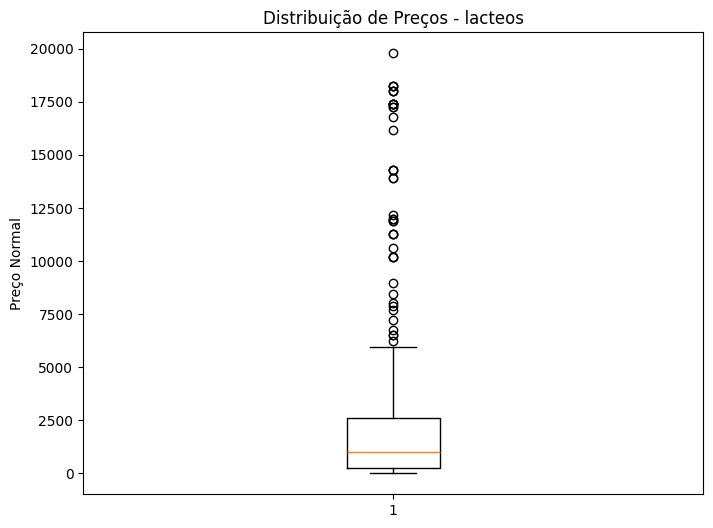

In [31]:
#Seu código aqui

maior_desvio_cat = df.groupby('Categoria')['Preco_Normal'].std().idxmax()


df_cat = df.loc[df['Categoria'] == maior_desvio_cat]

plt.figure(figsize=(8, 6))
plt.boxplot(df_cat['Preco_Normal'])
plt.title(f'Distribuição de Preços - {maior_desvio_cat}')
plt.ylabel('Preço Normal')
plt.show()

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

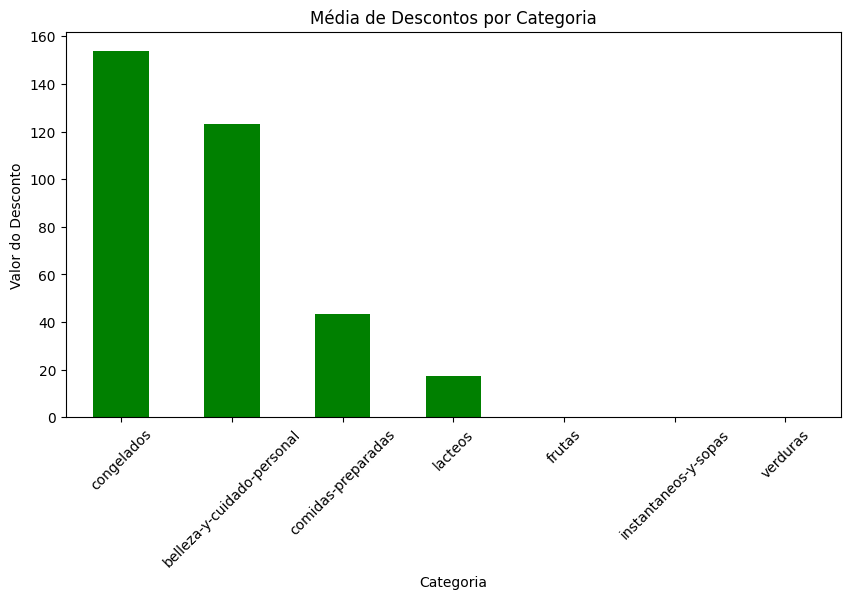

In [32]:
# Seu código aqui
media_desconto = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
media_desconto.plot(kind='bar', color='green')
plt.title('Média de Descontos por Categoria')
plt.ylabel('Valor do Desconto')
plt.xticks(rotation=45)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [33]:

df_mapa = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

fig = px.treemap(df_mapa,
                 path=['Categoria', 'Marca'],
                 values='Desconto',
                 title='Mapa Interativo de Descontos por Categoria e Marca')
fig.show()